In [21]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

In [22]:
from pathlib import Path
print(Path.cwd())

/Users/yanakhalitova/workspace/project-seminar/tsu-image-description/notebooks


In [23]:
out_dir = Path("/Users/yanakhalitova/workspace/project-seminar/tsu-image-description/data/eval/results")

with open(out_dir / "predictions_detailed.json", "r", encoding="utf-8") as f:
    rows = json.load(f)

with open(out_dir / "embeddings_manifest.json", "r", encoding="utf-8") as f:
    manifest = json.load(f)

emb = np.load(out_dir / "embeddings_clip.npz")

print("Arrays:", emb.files)
print("Rows in predictions:", len(rows))
print("Manifest:", manifest)
print("image_embeddings shape:", emb["image_embeddings"].shape)

Arrays: ['image_embeddings', 'reference_short_ru_embeddings', 'predicted_caption_ru_embeddings', 'predicted_caption_en_embeddings', 'archive_prediction_embeddings']
Rows in predictions: 20
Manifest: {'embedding_model': 'open_clip ViT-B-32', 'pretrained': 'openai', 'normalized': True, 'main_clipscore_variant': 'image ↔ predicted_caption_en', 'alignment_rule': 'row i in predictions_detailed.json corresponds to row i in every array in embeddings_clip.npz', 'arrays': ['image_embeddings', 'reference_short_ru_embeddings', 'predicted_caption_ru_embeddings', 'predicted_caption_en_embeddings', 'archive_prediction_embeddings']}
image_embeddings shape: (20, 512)


In [24]:
df = pd.DataFrame(rows)

df["image_name"] = df["image_path"].apply(lambda x: Path(x).name)

display(
    df[
        [
            "embedding_row_idx",
            "image_name",
            "reference_short_ru",
            "caption_ru_prediction",
            "caption_en_prediction",
            "clipscore",
            "latency_sec",
        ]
    ]
)

,embedding_row_idx,image_name,reference_short_ru,caption_ru_prediction,caption_en_prediction,clipscore,latency_sec
0,0,postcard_1.jpg,Сосновый лес,черно-белое фото деревьев в лесу,a black and white photo of trees in the woods,0.306977,1.117822
1,1,postcard_2.jpg,Зима в лесу. Картины деревенской жизни России.,Картина людей в лесу,a painting of people in the woods,0.309889,0.604300
2,2,postcard_3.jpg,"Галич. Вид на пруд , город и Рождественская це...",черно-белое фото реки,a black and white photo of a river,0.253839,0.570237
3,3,postcard_4.jpg,Девочка с лукошком.,ребенка с скрипкой,a child with a violin,0.315097,0.464070
4,4,postcard_5.jpg,"Эвенки-охотник, с охотничьей собакой .",Человек на олене,a man on a reindeer,0.334996,0.559651
5,5,postcard_6.jpg,Броненосный корабль 'Синоп',рисунок корабля в воде,a drawing of a ship in the water,0.305906,0.585777
6,6,postcard_7.jpg,Розы расцветают...,Роза с листом на ней,a rose with a leaf on it,0.300343,0.542710
7,7,postcard_8.jpg,Ветки распускающейся вербы и расписные пасхаль...,Карта с изображением цветка,a card with a picture of a flower,0.289869,0.521556
8,8,postcard_9.jpg,Гейша сидит у зеркала,"две женщины в кимоно, японский","two women in kimono, japan",0.302041,0.618137
9,9,postcard_10.jpg,Изображение цветов и девочки,три гравировки цветов и листьев,three engravings of flowers and leaves,0.220872,0.529446


In [30]:
n = len(rows)

X = np.concatenate(
    [
        emb["image_embeddings"],
        emb["predicted_caption_en_embeddings"],
    ],
    axis=0,
)

plot_rows = []

for i, row in enumerate(rows):
    plot_rows.append(
        {
            "sample_id": i,
            "kind": "image",
            "label": Path(row["image_path"]).name,
            "short_label": f"I{i+1}",
        }
    )

for i, row in enumerate(rows):
    plot_rows.append(
        {
            "sample_id": i,
            "kind": "reference_ru",
            "short_label": f"R{i+1}",
        }
    )

for i, row in enumerate(rows):
    plot_rows.append(
        {
            "sample_id": i,
            "kind": "prediction_archive",
            "short_label": f"P{i+1}",
        }
    )

plot_df = pd.DataFrame(plot_rows)
print("X shape:", X.shape)
display(plot_df.head(10))

X shape: (40, 512)


,sample_id,kind,label,short_label
0,0,image,postcard_1.jpg,I1
1,1,image,postcard_2.jpg,I2
2,2,image,postcard_3.jpg,I3
3,3,image,postcard_4.jpg,I4
4,4,image,postcard_5.jpg,I5
5,5,image,postcard_6.jpg,I6
6,6,image,postcard_7.jpg,I7
7,7,image,postcard_8.jpg,I8
8,8,image,postcard_9.jpg,I9
9,9,image,postcard_10.jpg,I10


In [32]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plot_df["x"] = X_pca[:, 0]
plot_df["y"] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))

markers = {
    "image": "o",
    "prediction": "^",
}

for kind, marker in markers.items():
    mask = plot_df["kind"] == kind
    ax.scatter(
        plot_df.loc[mask, "x"],
        plot_df.loc[mask, "y"],
        marker=marker,
        label=kind,
        alpha=0.8,
    )

for i in range(n):
    pts = plot_df[plot_df["sample_id"] == i].sort_values(
        by="kind",
        key=lambda s: s.map({"image": 0, "prediction_archive": 1})
    )
    ax.plot(pts["x"], pts["y"], alpha=0.35)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["short_label"],
        (row["x"], row["y"]),
        fontsize=8,
        alpha=0.85,
        # xytext=(4, 4),
        textcoords="offset points",
    )

ax.set_title("PCA-проекция CLIP-эмбеддингов")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

ValueError: Length of values (40) does not match length of index (60)

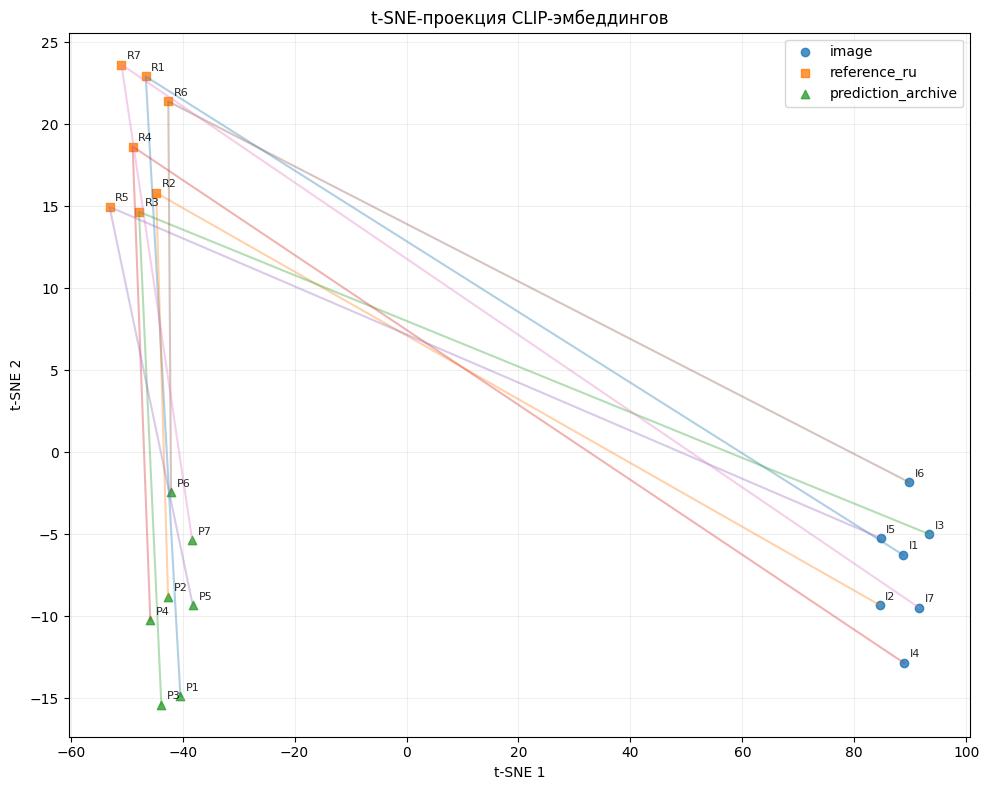

In [9]:
tsne = TSNE(
    n_components=2,
    perplexity=min(5, n - 1),
    init="pca",
    learning_rate="auto",
    random_state=42,
)

X_tsne = tsne.fit_transform(X)

plot_df["x_tsne"] = X_tsne[:, 0]
plot_df["y_tsne"] = X_tsne[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))

for kind, marker in markers.items():
    mask = plot_df["kind"] == kind
    ax.scatter(
        plot_df.loc[mask, "x_tsne"],
        plot_df.loc[mask, "y_tsne"],
        marker=marker,
        label=kind,
        alpha=0.8,
    )

for i in range(n):
    pts = plot_df[plot_df["sample_id"] == i].sort_values(
        by="kind",
        key=lambda s: s.map({"image": 0, "reference_ru": 1, "prediction_archive": 2})
    )
    ax.plot(pts["x_tsne"], pts["y_tsne"], alpha=0.35)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["short_label"],
        (row["x_tsne"], row["y_tsne"]),
        fontsize=8,
        alpha=0.85,
        xytext=(4, 4),
        textcoords="offset points",
    )

ax.set_title("t-SNE-проекция CLIP-эмбеддингов")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [10]:
image_emb = emb["image_embeddings"]
ref_emb = emb["reference_short_ru_embeddings"]
pred_emb = emb["archive_prediction_embeddings"]

sim_img_ref = cosine_similarity(image_emb, ref_emb)
sim_img_pred = cosine_similarity(image_emb, pred_emb)

print("sim_img_ref shape:", sim_img_ref.shape)
print("sim_img_pred shape:", sim_img_pred.shape)

sim_img_ref shape: (7, 7)
sim_img_pred shape: (7, 7)


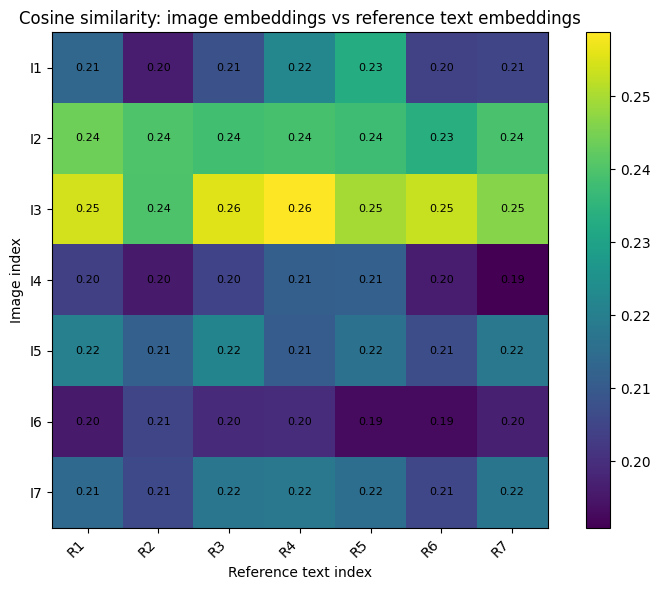

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_img_ref)

ax.set_title("Cosine similarity: image embeddings vs reference text embeddings")
ax.set_xlabel("Reference text index")
ax.set_ylabel("Image index")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"R{i+1}" for i in range(n)], rotation=45, ha="right")
ax.set_yticklabels([f"I{i+1}" for i in range(n)])

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_img_ref[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

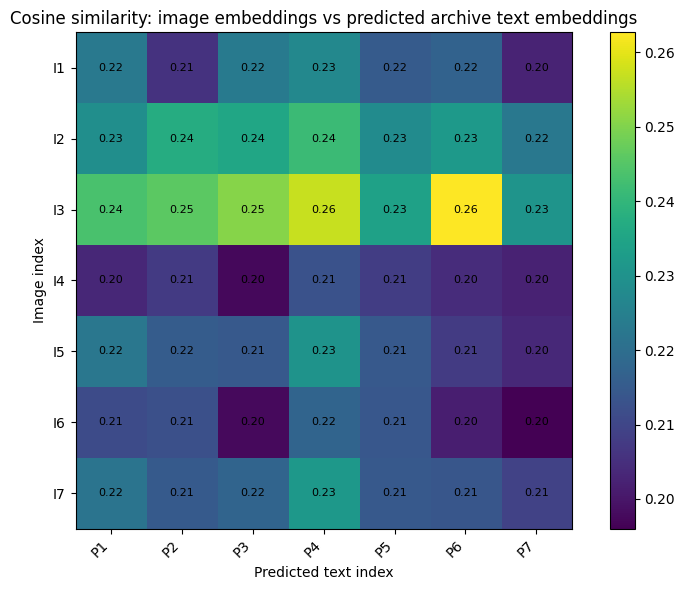

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_img_pred)

ax.set_title("Cosine similarity: image embeddings vs predicted archive text embeddings")
ax.set_xlabel("Predicted text index")
ax.set_ylabel("Image index")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"P{i+1}" for i in range(n)], rotation=45, ha="right")
ax.set_yticklabels([f"I{i+1}" for i in range(n)])

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_img_pred[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [13]:
diag_ref = np.diag(sim_img_ref)
diag_pred = np.diag(sim_img_pred)

diag_df = pd.DataFrame(
    {
        "sample_id": np.arange(1, n + 1),
        "image_name": [Path(r["image_path"]).name for r in rows],
        "sim_image_reference": diag_ref,
        "sim_image_prediction": diag_pred,
        "clipscore_saved": [r["clipscore"] for r in rows],
    }
)

display(diag_df)

,sample_id,image_name,sim_image_reference,sim_image_prediction,clipscore_saved
0,1,postcard_1.jpg,0.213303,0.222973,0.222973
1,2,postcard_2.jpg,0.240103,0.237188,0.237188
2,3,postcard_3.jpg,0.255429,0.250540,0.250540
3,4,postcard_4.jpg,0.211467,0.212719,0.212719
4,5,postcard_5.jpg,0.216296,0.214584,0.214584
5,6,postcard_6.jpg,0.192897,0.201604,0.201604
6,7,postcard_7.jpg,0.217367,0.209216,0.209216


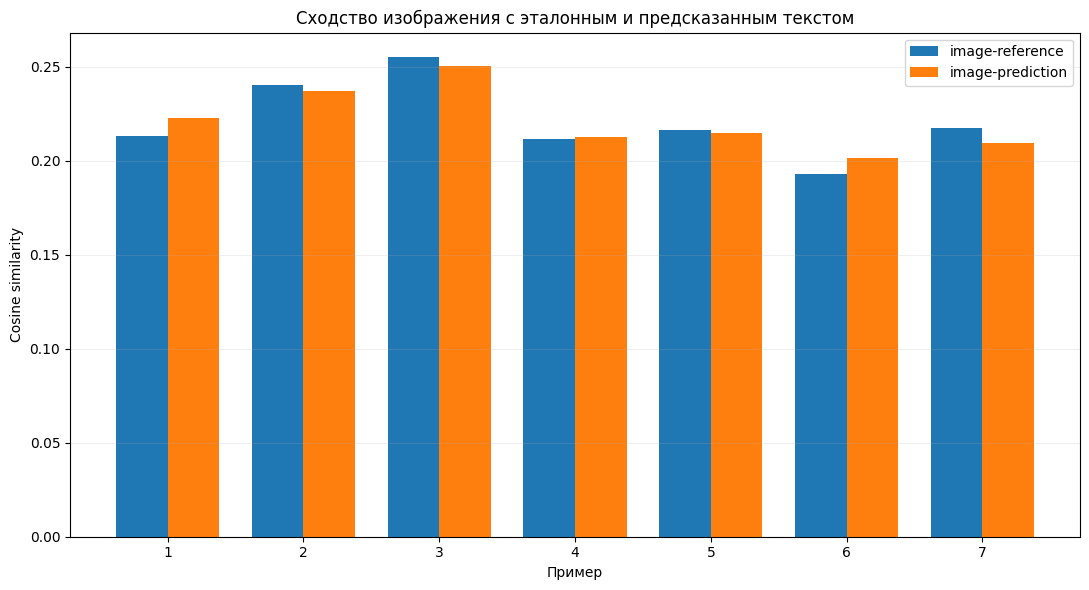

In [14]:
x = np.arange(n)
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, diag_df["sim_image_reference"], width, label="image-reference")
ax.bar(x + width/2, diag_df["sim_image_prediction"], width, label="image-prediction")

ax.set_title("Сходство изображения с эталонным и предсказанным текстом")
ax.set_xlabel("Пример")
ax.set_ylabel("Cosine similarity")
ax.set_xticks(x)
ax.set_xticklabels([f"{i+1}" for i in range(n)])
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [15]:
diag_df["gap_pred_minus_ref"] = (
    diag_df["sim_image_prediction"] - diag_df["sim_image_reference"]
)

display(diag_df.sort_values("sim_image_prediction").head(5))
display(diag_df.sort_values("gap_pred_minus_ref").head(5))

,sample_id,image_name,sim_image_reference,sim_image_prediction,clipscore_saved,gap_pred_minus_ref
5,6,postcard_6.jpg,0.192897,0.201604,0.201604,0.008706
6,7,postcard_7.jpg,0.217367,0.209216,0.209216,-0.008151
3,4,postcard_4.jpg,0.211467,0.212719,0.212719,0.001252
4,5,postcard_5.jpg,0.216296,0.214584,0.214584,-0.001712
0,1,postcard_1.jpg,0.213303,0.222973,0.222973,0.009669


,sample_id,image_name,sim_image_reference,sim_image_prediction,clipscore_saved,gap_pred_minus_ref
6,7,postcard_7.jpg,0.217367,0.209216,0.209216,-0.008151
2,3,postcard_3.jpg,0.255429,0.250540,0.250540,-0.004889
1,2,postcard_2.jpg,0.240103,0.237188,0.237188,-0.002915
4,5,postcard_5.jpg,0.216296,0.214584,0.214584,-0.001712
3,4,postcard_4.jpg,0.211467,0.212719,0.212719,0.001252


In [16]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

In [17]:
image_emb = emb["image_embeddings"]
pred_en_emb = emb["predicted_caption_en_embeddings"]

sim_img_pred_en = cosine_similarity(image_emb, pred_en_emb)
sim_img_pred_en.shape

(7, 7)

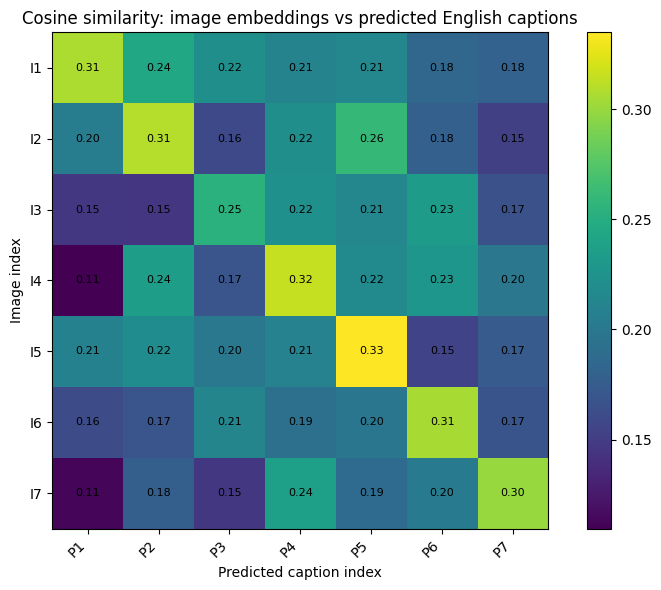

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_img_pred_en)

ax.set_title("Cosine similarity: image embeddings vs predicted English captions")
ax.set_xlabel("Predicted caption index")
ax.set_ylabel("Image index")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"P{i+1}" for i in range(n)], rotation=45, ha="right")
ax.set_yticklabels([f"I{i+1}" for i in range(n)])

for i in range(n):
    for j in range(n):
        ax.text(
            j, i,
            f"{sim_img_pred_en[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [19]:
best_match_idx = sim_img_pred_en.argmax(axis=1)
best_match_score = sim_img_pred_en.max(axis=1)

match_df = pd.DataFrame({
    "image_idx": np.arange(n),
    "image_name": [Path(r["image_path"]).name for r in rows],
    "best_prediction_idx": best_match_idx,
    "best_prediction_label": [f"P{i+1}" for i in best_match_idx],
    "best_prediction_score": best_match_score,
    "is_correct_diagonal": best_match_idx == np.arange(n),
})

match_df

,image_idx,image_name,best_prediction_idx,best_prediction_label,best_prediction_score,is_correct_diagonal
0,0,postcard_1.jpg,0,P1,0.306977,True
1,1,postcard_2.jpg,1,P2,0.309889,True
2,2,postcard_3.jpg,2,P3,0.253839,True
3,3,postcard_4.jpg,3,P4,0.315097,True
4,4,postcard_5.jpg,4,P5,0.334996,True
5,5,postcard_6.jpg,5,P6,0.305906,True
6,6,postcard_7.jpg,6,P7,0.300343,True


In [20]:
top1_accuracy = (best_match_idx == np.arange(n)).mean()
print("Top-1 matching accuracy:", round(float(top1_accuracy), 4))

Top-1 matching accuracy: 1.0
